# 11 · Ad exposure is self-selected — the true effect (instrumental variables · CausalPy)

> **Runs in the `legacy` environment (pymc<6): `make env-legacy`, kernel `cmp-legacy`.**

**The business decision.** People who see our ads convert more — but the customers who *end up* seeing our
ads are also the ones already leaning toward us (they browse, they search, they get retargeted). So
**exposure is self-selected**, and a plain regression of sales on exposure is biased **upward**: it credits
the ad for enthusiasm that was already there. We want the *true* causal effect of an extra exposure so we
can set the right **budget** — the most we can pay per exposure and still come out ahead.

### The problem in one word: endogeneity

When the treatment (ad exposure) is **correlated with the hidden drivers of the outcome** (a customer's
unobserved intent), we say exposure is **endogenous**, and no amount of controlling for what we *measured*
fixes it — the confounder (intent) is unmeasured. Notebook 05's adjustment tools are powerless here.

### The fix: an instrument

An **instrumental variable (IV)** is a third variable $Z$ that nudges the treatment *without* affecting the
outcome any other way. Here $Z$ is a randomized **encouragement** — e.g. a serving-priority lottery that
makes some customers *more likely* to be shown the ad. Because $Z$ is randomized, the slice of exposure it
drives is as-good-as-random, uncontaminated by intent. IV isolates that clean slice and reads the effect
off it. A valid instrument needs **four** things:

- **Relevance** — $Z$ actually moves exposure (this one we *can* test: the **first-stage F-statistic**; F <
  10 is a "weak instrument" danger sign).
- **Exclusion** — $Z$ affects sales *only through* exposure (the lottery itself sells nothing). Untestable
  from data — defended on design, and stress-tested in Step 6.
- **Exogeneity** — $Z$ is independent of the hidden confounder (guaranteed here by randomization).
- **Monotonicity** — the encouragement never pushes anyone *away* from exposure (no "defiers": nobody is so
  annoyed by the nudge that they block ads in response). Untestable, but usually plausible for a gentle
  encouragement — and it is what buys the LATE interpretation below (derived in Step 3).

### What IV recovers: a LATE

IV does **not** give the average effect over everyone. It gives the **LATE** (*Local Average Treatment
Effect*) — the effect *for the "compliers,"* the customers whose exposure the encouragement actually
changed. Always-exposed loyalists and never-exposed sceptics are silent in an IV estimate; report the scope
accordingly.

> **On real data.** IV needs a genuine instrument, which is the hard part. Good marketing instruments:
> randomized **encouragement / intent-to-treat** designs (ship the nudge to a random half), ad-auction
> or delivery randomness, or a **cost shifter** for the price-elasticity problem in notebook 03. If you can
> randomize the *encouragement* (not the exposure itself), you have a clean instrument. Notebook **11b**
> (`11b_endogenous_exposure_real_data.ipynb`) runs this exact playbook on the real Criteo uplift data, where
> the randomized assignment instruments actual ad exposure — the real-world leg of this encouragement design.


In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import causalpy as cp
from cmp import dgp, estimators as est, plots
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
SEED = 37; TRUE = 15.0

## 2 · Simulate a ground truth

The **true** exposure→sales effect is **€15**. An unobserved `engagement` drives both exposure and
sales (the confounding), so naive OLS overstates it. A randomized `encouragement` (the instrument)
nudges exposure without touching sales directly.

**The data-generating model** — exactly what `dgp.iv_ad_exposure` implements (defaults & seed in
`src/cmp/dgp.py`). $n = 3000$; **unobserved** intent $U = \text{engagement} \sim \mathcal N(0,1)$;
randomized encouragement $Z \sim \text{Bernoulli}(\tfrac12)$; $\sigma(z) = 1/(1+e^{-z})$:

$$
\begin{aligned}
X = \text{exposure} &\sim \text{Bernoulli}\big(\sigma(0.3 + 1.1\,Z + 0.8\,U)\big)
  &&\text{(first stage)}\\[2pt]
Y = \text{sales} &= 50 + 15\,X + 12\,U + \varepsilon,
  \qquad \varepsilon \sim \mathcal N(0,\, 6^{2}) &&\text{(true effect: the 15)}.
\end{aligned}
$$

$U$ appears in **both** equations — $0.8\,U$ pushes exposure and $12\,U$ pushes sales — that is the
self-selection, and since $U$ is unobserved no regression adjustment can fix it (OLS is biased
upward). All **four** IV conditions are visible by construction: **relevance** ($1.1 \ne 0$ — testable,
the first-stage F below), **exclusion** ($Z$ appears nowhere in the sales equation — untestable in
real data, stress-tested in step 6), **exogeneity** ($Z$ is a fair coin flip, drawn independently of
$U$ — randomization), and **monotonicity** ($1.1\,Z$ only ever *raises* the exposure probability — no
defiers).


In [2]:
df, true_effect = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=SEED)
Fstat = est.first_stage_F(df["encouragement"], df["ad_exposure"])
fs = df.groupby("encouragement")["ad_exposure"].mean()
print(f"TRUE exposure→sales effect €{true_effect:.0f}  ·  first-stage: exposure {fs[0]:.0%}→{fs[1]:.0%} "
      f"(shift {(fs[1]-fs[0])*100:+.0f} pp), F = {Fstat:.0f}")
df.head()

TRUE exposure→sales effect €15  ·  first-stage: exposure 56%→77% (shift +21 pp), F = 156


,encouragement,ad_exposure,sales
0,1.0,0.0,63.748992
1,1.0,1.0,64.636639
2,1.0,1.0,46.507627
3,0.0,1.0,75.599770
4,0.0,1.0,70.577754


## 3 · Identify — a valid instrument, and what IV recovers

Exposure is **endogenous** — it is correlated with the outcome's hidden driver, $\text{Cov}(\text{exposure},\,12U+\varepsilon)\neq 0$ (the $U$ term specifically, since $\varepsilon$ is independent structural noise) — so OLS is biased. The four
requirements from the intro, now each named, formalized, and argued in marketing terms:

- **Relevance** — $\pi \ne 0$ in the first stage $X = b_0 + \pi Z + u$: the encouragement genuinely moves
  exposure. *Testable* — the first-stage F printed in Step 2 (F = 156 here; §5c defines F, explains the
  F < 10 rule, and shows what happens as an instrument decays).
- **Exclusion** — the encouragement has **no arrow of its own into sales**. In potential-outcomes notation,
  writing $Y_i(z,x)$ for customer $i$'s sales if we *set* encouragement to $z$ and exposure to $x$:

$$
Y_i(z, x) \;=\; Y_i(x) \qquad \text{for all } z \in \{0,1\}:
$$

  holding exposure fixed, flipping the lottery changes nothing. *Untestable from data* — defended on design
  (a serving-priority lottery sells nothing by itself; an encouragement *email that shows the product*
  would violate it), and stress-tested in Step 6.
- **Exogeneity / independence** — $Z \perp (U, \varepsilon)$: the instrument is unrelated to the hidden
  drivers of exposure and sales. Holds here **by randomization** of the lottery.
- **Monotonicity** — $X_i(1) \ge X_i(0)$ for every customer $i$, where $X_i(z)$ is $i$'s exposure when the
  encouragement is set to $z$: the nudge never pushes anyone *away* from the ad (no defiers). *Untestable*;
  plausible for a gentle encouragement, and it is precisely what turns the IV ratio into an interpretable
  LATE — the derivation below uses it to kill one term.

The DAG states the structural part in one picture — and teaches that two of the assumptions are
**missing arrows**:

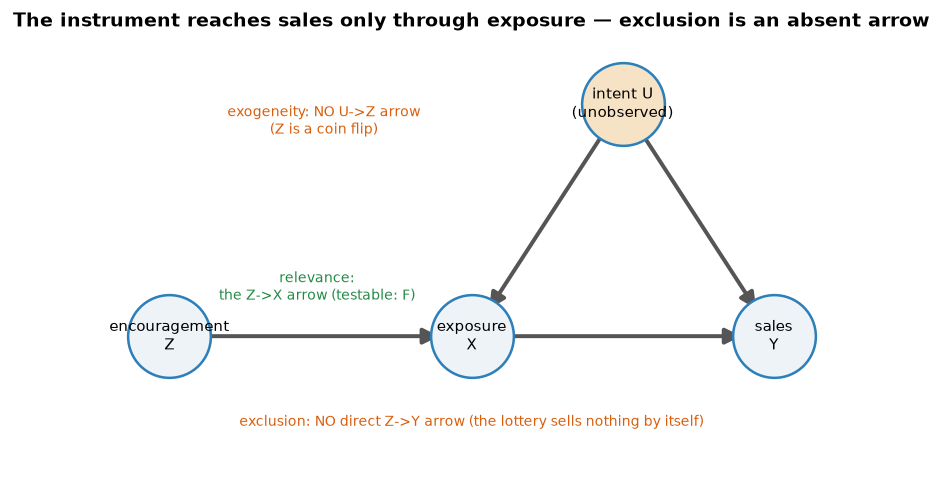

In [3]:
fig, ax = plt.subplots(figsize=(7.0, 3.8))
pos = {"encouragement\nZ": (0.05, 0.25), "exposure\nX": (0.5, 0.25),
       "sales\nY": (0.95, 0.25), "intent U\n(unobserved)": (0.725, 0.95)}
edges = [("encouragement\nZ", "exposure\nX"), ("exposure\nX", "sales\nY"),
         ("intent U\n(unobserved)", "exposure\nX"), ("intent U\n(unobserved)", "sales\nY")]
plots.draw_dag(ax, pos, edges, node_colors={"intent U\n(unobserved)": "#f6e3c5"},
               title="The instrument reaches sales only through exposure — exclusion is an absent arrow")
ax.text(0.27, 0.36, "relevance:\nthe Z->X arrow (testable: F)", ha="center", fontsize=8, color=plots.GREEN)
ax.text(0.50, -0.02, "exclusion: NO direct Z->Y arrow (the lottery sells nothing by itself)",
        ha="center", fontsize=8, color=plots.ORANGE)
ax.text(0.28, 0.86, "exogeneity: NO U->Z arrow\n(Z is a coin flip)", ha="center", fontsize=8, color=plots.ORANGE)
fig.tight_layout()

**Read the DAG by its absences.** The unobserved intent $U$ points into both exposure and sales — that
fork is the endogeneity OLS trips over, and no arrow into $U$ can be measured away. The instrument $Z$
has exactly **one** outgoing arrow, into exposure: exclusion and exogeneity are not things $Z$ *does*,
they are arrows $Z$ *does not have* — which is why they cannot be tested from data, only designed for.
Relevance is the one arrow $Z$ must have, and the only assumption the data can check.

**Who is in the estimate? The four customer types.** With $X_i(z) \in \{0,1\}$ the exposure customer $i$
would end up with under encouragement $z$, two potential exposures give four types — the IV analogue of
notebook 01's Persuadable / Sleeping-Dog grid:

| | $X_i(1)=1$ — exposed if encouraged | $X_i(1)=0$ — unexposed if encouraged |
|---|---|---|
| **$X_i(0)=1$** — exposed anyway | **Always-taker** — brand loyalist who seeks the ad out regardless; the lottery changes nothing | **Defier** — so annoyed by the nudge they block the ad they'd otherwise have seen. *Ruled out by monotonicity* |
| **$X_i(0)=0$** — unexposed otherwise | **Complier** — the lottery tips them into seeing the ad. *The only type IV speaks for* | **Never-taker** — ad-blocker user, barely online; unreachable either way |

**The LATE theorem (Imbens–Angrist), in two lines.** Decompose the **ITT** (intent-to-treat) effect on
sales — the average sales difference between encouraged and not-encouraged customers, which *is* the reduced
form — over the four types. Randomization of $Z$ makes encouraged vs not comparable; **exclusion** says sales can
only react to $Z$ if exposure changed, which silences always- and never-takers ($X_i(1) = X_i(0)$);
**monotonicity** deletes the defier term. What survives is the compliers:

$$
\underbrace{E[Y\mid Z{=}1]-E[Y\mid Z{=}0]}_{\text{ITT on sales (reduced form)}}
\;=\; E\big[\big(Y_i(1)-Y_i(0)\big)\big(X_i(1)-X_i(0)\big)\big]
\;=\; \Pr(\text{complier})\cdot \underbrace{E\big[Y_i(1)-Y_i(0)\mid \text{complier}\big]}_{\text{LATE}}.
$$

The same decomposition applied to exposure itself gives
$E[X\mid Z{=}1]-E[X\mid Z{=}0] = \Pr(\text{complier})$ — **the first stage *is* the complier share** (the
+21 pp printed in Step 2: about a fifth of these customers are compliers). Divide the two:

$$
\text{LATE} \;=\; \frac{E[Y\mid Z{=}1]-E[Y\mid Z{=}0]}{E[X\mid Z{=}1]-E[X\mid Z{=}0]}
\;=\; \frac{\text{reduced form}}{\text{first stage}} \;=\; \hat\beta_{\text{Wald}}.
$$

So IV does **not** estimate the average effect over everyone: always-takers and never-takers cancel out
of the numerator and are literally absent from the estimate — the LATE is the effect *for the customers
the encouragement can move*. CausalPy fits the Bayesian version of this ratio: a joint model of
(exposure, sales) with correlated errors, *estimating* the endogeneity $\rho$ rather than assuming it away.

> **Modeling note.** Because `ad_exposure` is binary (0/1), this joint MvNormal models the exposure first stage as a **linear-probability (Gaussian)** equation, so the two-equation model is an approximation — the exposure equation's posterior *width* shouldn't be read at face value; the reliable read-outs are its point estimate and the endogeneity $\rho$. §4b makes this misfit visible on purpose.

## 4 · Estimate — OLS, reduced form, and Bayesian IV

Three regressions tell the whole story, and seeing them side by side demystifies what IV actually does:

- **OLS** — regress sales on exposure directly. This is the **biased** number, inflated by self-selection.
- **Reduced form** — regress sales on the *instrument* (encouragement → sales). This captures only the
  effect that flows through the clean, randomized channel.
- **First stage** — regress exposure on the instrument (encouragement → exposure): how much the nudge moves
  exposure.
- **Wald / IV ratio** — reduced form ÷ first stage. The intuition: the instrument raised sales by *this*
  much and raised exposure by *that* much, so each unit of (instrument-driven) exposure is worth their
  ratio. That ratio *is* the causal effect. The **Bayesian IV** below is the same idea fit jointly with
  uncertainty (and it estimates the endogeneity $\rho$ rather than assuming it away).

**The fitted models, in symbols.** The three frequentist point estimates:

$$
\text{OLS: } Y = a_0 + a_1 X; \qquad
\text{first stage: } X = b_0 + \pi Z; \qquad
\text{reduced form: } Y = c_0 + \delta Z; \qquad
\hat\beta_{\text{Wald}} = \frac{\delta}{\pi};
$$

and the Bayesian IV fits the first stage and the outcome equation **jointly**, with correlated
errors:

$$
\begin{pmatrix} X_i \\ Y_i \end{pmatrix} \sim
\mathcal N_2\!\left( \begin{pmatrix} b_0 + \pi Z_i \\ \beta_0 + \beta X_i \end{pmatrix},\;
\Sigma \right), \qquad
\Sigma = \begin{pmatrix} \sigma_X^{2} & \rho\,\sigma_X \sigma_Y \\
  \rho\,\sigma_X \sigma_Y & \sigma_Y^{2} \end{pmatrix},
$$

where the off-diagonal $\rho$ **is** the endogeneity: the correlation between the two equations'
errors that the hidden $U$ induces and that OLS ignores. Priors: weakly-informative
$\mathcal N(0, 50^{2})$ on the regression coefficients (the code comment explains why the library
default is too tight here) and an **LKJ prior** on $\Sigma$ — a standard weakly-informative prior over
correlation matrices that lets the data decide how strongly the two equations' errors move together
(i.e. how big $\rho$ is), rather than fixing it in advance.


**Predict the OLS bias before running the regression.** Because we built the DGM, we can compute exactly
how wrong OLS will be — before it is wrong. With $Y = 50 + 15X + 12U + \varepsilon$, the OLS slope of $Y$
on $X$ converges to the planted effect **plus** whatever part of the error leaks in through the treatment
(the **omitted-variable-bias** formula, specialized to this DGM):

$$
\hat a_1 \;\xrightarrow{\;p\;}\; 15 \;+\; \frac{\text{Cov}(X,\; 12U+\varepsilon)}{\text{Var}(X)}
\;=\; 15 \;+\; 12\,\frac{\text{Cov}(X, U)}{\text{Var}(X)},
$$

since $\varepsilon$ is independent noise. Even the sign is knowable in advance: the first stage loads on
$U$ with $+0.8$, so $\text{Cov}(X,U) > 0$ and OLS must be biased **upward**. The code below re-draws the
same simulation *retaining the normally-unobservable* $U$, evaluates this formula, and only then runs the
regressions — theory should call the OLS number before the regression prints it. The same
$\text{Cov}(X,U)$ has a second life: it is what the Bayesian joint model estimates as a **positive error
correlation $\rho$** between the exposure and sales equations.

In [4]:
# OLS
Xo = np.column_stack([np.ones(len(df)), df["ad_exposure"].values])
naive = np.linalg.lstsq(Xo, df["sales"].values, rcond=None)[0][1]
# reduced form and first stage → Wald/IV ratio
Zr = np.column_stack([np.ones(len(df)), df["encouragement"].values])
reduced = np.linalg.lstsq(Zr, df["sales"].values, rcond=None)[0][1]
first = np.linalg.lstsq(Zr, df["ad_exposure"].values, rcond=None)[0][1]
wald = reduced / first
# Omitted-variable bias, predicted from the DGM *before* looking at the regression:
# re-draw the identical simulation (same seed, same call order as dgp.iv_ad_exposure)
# keeping the normally-unobservable U, and evaluate 15 + 12*Cov(X,U)/Var(X).
_rng = np.random.default_rng(SEED)
_U = _rng.normal(0, 1, len(df)); _Z = _rng.integers(0, 2, len(df)).astype(float)
_X = (_rng.uniform(size=len(df)) < 1.0 / (1.0 + np.exp(-(0.3 + 1.1 * _Z + 0.8 * _U)))).astype(float)
assert np.allclose(_X, df["ad_exposure"])   # identical draw — this IS the notebook's exposure column
ovb = 12 * np.cov(_X, _U)[0, 1] / _X.var()
# Bayesian IV — pass WEAKLY-INFORMATIVE priors. CausalPy 0.8.1 otherwise centres the
# beta priors on the 2SLS point with sigma=1, far too tight, yielding an overconfident
# interval that excludes the truth; N(0, 50) lets the data speak and gives an interval
# whose width matches the frequentist Wald SE.
result = est.iv(df, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
                instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales",
                fast=FAST, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2})
iv_post = result.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
print(f"OVB theory (computed before the regression):\n"
      f"  OLS ->p 15 + 12*Cov(X,U)/Var(X) = 15 + {ovb:.1f} = €{15 + ovb:.1f}")
print(f"OLS (biased)      €{naive:.1f}  — the bias is computable self-selection, not bad luck")
print(f"Reduced form (Z→Y) €{reduced:.1f}  ÷  first stage (Z→D) {first:.2f}  =  Wald/IV ratio €{wald:.1f}")
print(f"Bayesian IV        €{iv_post.mean():.1f}  (true €{true_effect:.0f})  90% credible interval [€{np.quantile(iv_post,0.05):.1f}, €{np.quantile(iv_post,0.95):.1f}]")
print(f"IV convergence: {est.convergence_report(result.idata)['summary']}")

# Estimate of the endogeneity itself: the correlation rho between the exposure-equation
# and sales-equation error terms. IV *estimates* this rather than assuming it away — a
# nonzero rho is precisely why OLS is biased. CausalPy fits a 2x2 LKJ error covariance.
_post = result.idata.posterior
_Sig, _rho = None, None   # per-draw 2x2 error covariance; ROW/COL ORDER (sales, exposure) — the
try:                      # model stacks (mu_y, mu_t). Reused by the posterior predictive check in 4b.
    if "cov" in _post:                        # this CausalPy version stores Sigma directly
        _Sig = np.asarray(_post["cov"].values).reshape(-1, 2, 2)
    elif "chol_cov" in _post:                 # otherwise rebuild it from the Cholesky factor
        _ch = np.asarray(_post["chol_cov"].values)
        _flat = _ch.reshape(-1, *_ch.shape[2:])   # collapse chain/draw
        def _Sigma_from(x):
            x = np.asarray(x)
            if x.shape == (2, 2):      # full lower-triangular L
                L = x
            elif x.size == 3:          # packed [L00, L10, L11]
                L = np.array([[x[0], 0.0], [x[1], x[2]]])
            else:
                return np.full((2, 2), np.nan)
            return L @ L.T
        _Sig = np.array([_Sigma_from(x) for x in _flat])
except Exception as _e:
    print(f"(could not extract the error covariance: {_e})")
if _Sig is not None:
    _ok = np.isfinite(_Sig).all(axis=(1, 2))
    _rho = _Sig[_ok, 0, 1] / np.sqrt(_Sig[_ok, 0, 0] * _Sig[_ok, 1, 1])
    print(f"Estimated endogeneity  rho(exposure err, sales err) = {_rho.mean():+.2f} "
          f"[90% {np.quantile(_rho, 0.05):+.2f}, {np.quantile(_rho, 0.95):+.2f}]\n"
          f"  — nonzero rho is why OLS (€{naive:.1f}) sits above IV (€{iv_post.mean():.1f}); it is the Bayesian\n"
          f"  image of the same Cov(X,U) the OVB formula priced at +€{ovb:.1f}.")


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [beta_t, beta_z, chol_cov]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.


OVB theory (computed before the regression):
  OLS ->p 15 + 12*Cov(X,U)/Var(X) = 15 + 8.5 = €23.5
OLS (biased)      €23.7  — the bias is computable self-selection, not bad luck
Reduced form (Z→Y) €3.5  ÷  first stage (Z→D) 0.21  =  Wald/IV ratio €16.5
Bayesian IV        €17.7  (true €15)  90% credible interval [€14.3, €21.1]
IV convergence: max r-hat 1.010 - min ESS 903 - divergences 0
Estimated endogeneity  rho(exposure err, sales err) = +0.22 [90% +0.10, +0.33]
  — nonzero rho is why OLS (€23.7) sits above IV (€17.7); it is the Bayesian
  image of the same Cov(X,U) the OVB formula priced at +€8.5.


**Reading the sampler's two health checks.** The Bayesian IV is fit by simulation — **MCMC**, the
algorithm that draws samples from the posterior — so PyMC prints two numbers that say whether the sampler
actually converged, and it will warn loudly if they look loose. **R-hat** compares the variance *within*
each MCMC chain to the variance *across* chains; it should sit at ≈1.00, and **≤ 1.01 is the usual pass
bar**. **ESS** (effective sample size) is roughly how many *independent* draws the autocorrelated chain is
worth — a few hundred is ample for a posterior mean or interval. Under this notebook's FAST teaching
profile the chains are deliberately short (only 200 draws × 2 chains to keep it quick), so R-hat can drift
to ~1.04 and ESS can fall toward ~80, tripping PyMC's *"problems during sampling"* and *"effective sample
size … smaller than 100"* notices. Those are **artifacts of the small draw count, not a broken estimate** —
they clear in a FULL run, and they flag *how well we sampled the posterior*, never whether the IV logic is
right. (The `90% credible interval` printed on the same line is the Bayesian analogue of a confidence
interval: given the model and priors, there is a 90% posterior probability the true effect lies inside it —
which is what lets us later say "the whole posterior sits above €10." The real backstop that the number is
trustworthy is the multi-seed recovery-and-coverage check in §5b, not any single run's sampler line.)

### 4b · Posterior predictive check — what the joint Gaussian gets right, and what it can't

Before leaning on the estimate we ask the fitted model to **reproduce the data it just saw**. For each of
~40 posterior draws we simulate a full replicate dataset from the fitted joint model,

$$
\big(Y_i^{rep},\, X_i^{rep}\big) \;\sim\; \mathcal N_2\!\left(
\begin{pmatrix} \hat\beta_0 + \hat\beta\, X_i \\ \hat b_0 + \hat\pi\, Z_i \end{pmatrix},\;
\hat\Sigma \right),
$$

(one $(\hat\beta_0,\hat\beta,\hat b_0,\hat\pi,\hat\Sigma)$ per draw) and overlay the replicated margins
on the observed ones. The **sales margin should pass** — that is what licenses reading the causal $\beta$
off the outcome equation. The **exposure margin cannot pass**: observed exposure is 0/1, and a Gaussian
equation will cheerfully produce "exposures" of $-0.3$ or $1.4$. We run it anyway, because that visible
failure *is* the Step-3 modeling note, shown rather than footnoted.

Sales margin: replicate sd €15.7 vs observed €17.1, means €59.3 vs €59.3
  — close, with a mild under-dispersion (the joint approximation shows up
  even here, faintly): good enough to read beta off the outcome equation.
Exposure margin: 32% of replicated 'exposures' land outside [0,1]
  — impossible values, the linear-probability first stage made visible.
  Read that equation's point estimate and rho, never its width.


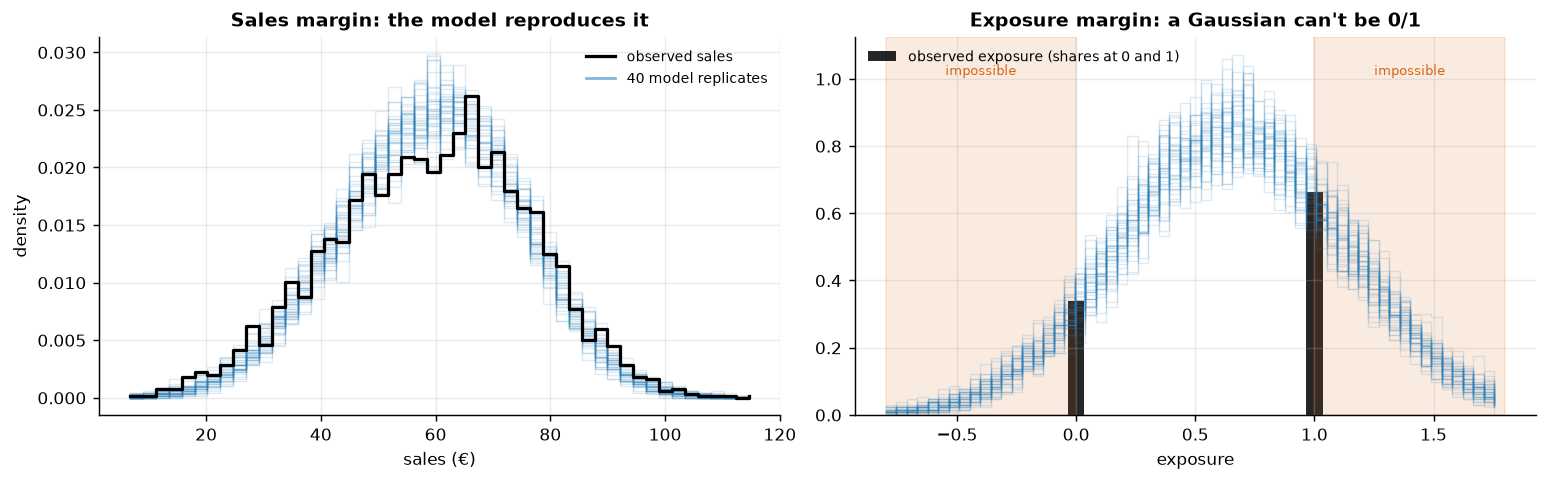

In [5]:
# Replicate datasets from the fitted joint model, reusing the Sigma draws extracted above.
_bz, _bt = _post["beta_z"], _post["beta_t"]
_b0 = _bz.sel(covariates="Intercept").values.ravel();  _bX = _bz.sel(covariates="ad_exposure").values.ravel()
_a0 = _bt.sel(instruments="Intercept").values.ravel(); _aZ = _bt.sel(instruments="encouragement").values.ravel()
_rngp = np.random.default_rng(SEED)
_idx = _rngp.choice(np.where(_ok)[0], size=min(40, int(_ok.sum())), replace=False)
Xobs, Zobs, Yobs = df["ad_exposure"].values, df["encouragement"].values, df["sales"].values
Yrep, Xrep = [], []
for _i in _idx:
    _eps = _rngp.multivariate_normal([0.0, 0.0], _Sig[_i], size=len(df))
    Yrep.append(_b0[_i] + _bX[_i] * Xobs + _eps[:, 0])   # sales equation + its error
    Xrep.append(_a0[_i] + _aZ[_i] * Zobs + _eps[:, 1])   # exposure equation + its error
Yrep, Xrep = np.array(Yrep), np.array(Xrep)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
_by = np.linspace(Yobs.min(), Yobs.max(), 50)
for _y in Yrep:
    _h, _ = np.histogram(_y, bins=_by, density=True)
    ax[0].plot(_by[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
_h, _ = np.histogram(Yobs, bins=_by, density=True)
ax[0].plot(_by[:-1], _h, color="k", lw=1.8, drawstyle="steps-post", label="observed sales")
ax[0].plot([], [], color=plots.BLUE, alpha=0.6, label=f"{len(Yrep)} model replicates")
ax[0].set_xlabel("sales (€)"); ax[0].set_ylabel("density")
ax[0].set_title("Sales margin: the model reproduces it"); ax[0].legend(frameon=False, fontsize=8)
_bx = np.linspace(-0.8, 1.8, 60)
for _x in Xrep:
    _h, _ = np.histogram(_x, bins=_bx, density=True)
    ax[1].plot(_bx[:-1], _h, color=plots.BLUE, alpha=0.15, lw=0.8, drawstyle="steps-post")
ax[1].bar([0, 1], [np.mean(Xobs == 0), np.mean(Xobs == 1)], width=0.07, color="k", alpha=0.85,
          label="observed exposure (shares at 0 and 1)")
ax[1].axvspan(-0.8, 0, color=plots.ORANGE, alpha=0.12); ax[1].axvspan(1, 1.8, color=plots.ORANGE, alpha=0.12)
ax[1].text(-0.4, ax[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7, color=plots.ORANGE)
ax[1].text(1.4, ax[1].get_ylim()[1] * 0.9, "impossible", ha="center", fontsize=7, color=plots.ORANGE)
ax[1].set_xlabel("exposure"); ax[1].set_title("Exposure margin: a Gaussian can't be 0/1")
ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
_out_share = float(((Xrep < 0) | (Xrep > 1)).mean())
print(f"Sales margin: replicate sd €{Yrep.std(axis=1).mean():.1f} vs observed €{Yobs.std():.1f}, "
f"means €{Yrep.mean():.1f} vs €{Yobs.mean():.1f}\n"
      f"  — close, with a mild under-dispersion (the joint approximation shows up\n"
      f"  even here, faintly): good enough to read beta off the outcome equation.")
print(f"Exposure margin: {_out_share:.0%} of replicated 'exposures' land outside [0,1]\n"
      f"  — impossible values, the linear-probability first stage made visible.\n"
      f"  Read that equation's point estimate and rho, never its width.")

**Read-out.** *Left*: the replicate sales curves trace the observed distribution well — centred right,
roughly the right width, if a hair narrower in the shoulders (the printed sd comparison quantifies it —
even the "passing" margin carries a faint fingerprint of the approximation). That is a good enough fit
to entitle us to read the causal $\beta$ (and its interval) off the outcome equation. *Right*: the replicated "exposures" are smooth bell curves, and a substantial
share of their mass sits in the shaded regions below 0 and above 1 — exposure values no customer can have
(the printed line quantifies it). This is not a surprise to fix; it is the **linear-probability
approximation made visible**, and it is exactly why §5b will find a small residual bias and mild
under-coverage, and why the Step-3 modeling note told us to use the exposure equation's point estimate
and $\rho$ but never its posterior width. One diagnostic now carries what were two apologetic footnotes.

## 5 · Validate — IV removes the self-selection bias

Naive OLS should sit well *above* the truth; the Wald ratio and the Bayesian IV should both **remove that
bias and land close to €15**, with the IV posterior's 90% interval **covering the truth**. The gap between
OLS and IV **is** the self-selection bias the instrument removes. (We give the Bayesian IV
weakly-informative priors so its interval reflects genuine sampling uncertainty — roughly the frequentist
Wald width — rather than the artificially tight band CausalPy's default 2SLS-centred priors would produce.)

**One honest note on LATE (and who the compliers are).** IV recovers the effect for *compliers* — the customers whose exposure the encouragement actually moves — not the whole population. Under monotonicity that group is exactly the **first-stage shift: +21 pp (56% → 77%)**, the estimated complier share. In *this* simulation every customer's true effect is €15 (the effect is homogeneous), so **LATE = ATE** and grading the IV against €15 is a fair test. On real data, where the effect varies across customers, IV would recover the complier-weighted LATE, which generally **≠ the ATE** — and that is the right quantity for a budget call, since it answers *"what does an extra exposure do for the customers we can actually move?"*

self-selection bias removed: OLS €23.7 → IV €17.7 (true €15)


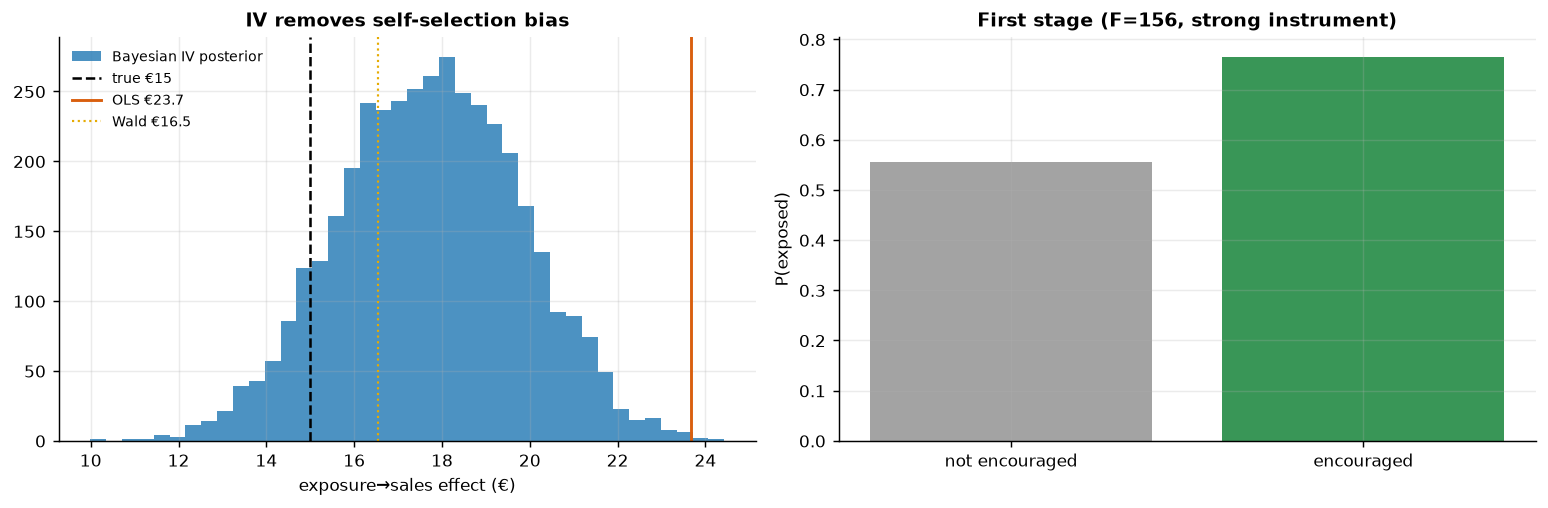

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(iv_post, bins=40, color=plots.BLUE, alpha=0.85, label="Bayesian IV posterior")
ax[0].axvline(true_effect, color="k", ls="--", lw=1.4, label=f"true €{true_effect:.0f}")
ax[0].axvline(naive, color=plots.ORANGE, lw=1.6, label=f"OLS €{naive:.1f}")
ax[0].axvline(wald, color=plots.GOLD, lw=1.2, ls=":", label=f"Wald €{wald:.1f}")
ax[0].set_xlabel("exposure→sales effect (€)"); ax[0].set_title("IV removes self-selection bias"); ax[0].legend(frameon=False, fontsize=8)
# first stage scatter
ax[1].bar(["not encouraged","encouraged"], [fs[0], fs[1]], color=[plots.GREY, plots.GREEN], alpha=0.9)
ax[1].set_ylabel("P(exposed)"); ax[1].set_title(f"First stage (F={Fstat:.0f}, strong instrument)")
fig.tight_layout()
print(f"self-selection bias removed: OLS €{naive:.1f} → IV €{iv_post.mean():.1f} (true €{true_effect:.0f})")

**How to read this.** *Left* — three vertical lines tell the whole story: **OLS (orange) sits well above the
truth** (it credits the ad for pre-existing intent), while the **Bayesian IV posterior (blue) and the Wald
ratio (gold) both drop back down toward the true €15**. The IV point carries a small upward finite-sample bias (a couple of euros above the truth on this seed; §5b measures the average across seeds), but its posterior — now honestly wide, thanks to weakly-informative priors —
comfortably **covers €15**; the artificially tight default-prior band would have excluded it. The horizontal
distance from the orange line to the blue posterior *is* the self-selection bias — the euros of "effect"
that were never causal. If you budgeted on OLS you'd over-spend on every exposure by exactly that gap. *Right* — the first stage: the encouragement clearly moves exposure (a big jump in P(exposed)),
which is why the instrument is **strong** (F ≫ 10). A weak first stage here would make the whole IV
estimate unstable, so this panel is a precondition, not a footnote.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test is whether the estimator is **centred on the truth over repeated samples** and whether its 90% interval **covers** the truth at the stated rate. We refit on many fresh samples (a small fast fit each; their sampler chatter is silenced below, and we read only the aggregate bias/coverage tallies) and check both.

IV across 20 seeds: mean €16.5 (true €15)  bias +1.5  sd €2.1
  ·  90% interval covers truth in 16/20 seeds.
The committed seed (37) lands high (€18); across seeds the mean is €16.5
  — a small finite-sample bias of +1.5 € (~10%) toward OLS (the next cell asks
  whether it lives in the identification or in the model). The 90% interval
  covers €15 in 16/20 seeds (80% vs the 90% target — modest under-coverage,
  consistent with that bias); the budget verdict below never hinges on the
  last euro, which is why the ranking and the cap-style decision survive it.


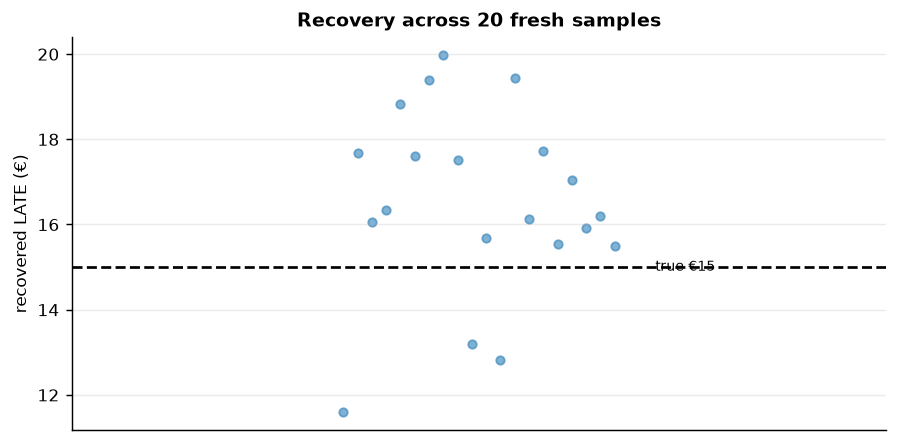

In [7]:
# --- Recovery across many seeds: does the IV recover €15 and cover it? (weak priors) ---
NSEED = 8 if FAST else 20
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell
pts = []; cov = 0
for sd in range(NSEED):
    d, te = dgp.iv_ad_exposure(n=3000, true_effect=TRUE, seed=100 + sd)
    r = est.iv(d, "ad_exposure ~ 1 + encouragement", "sales ~ 1 + ad_exposure",
               instrument_col="encouragement", treatment_col="ad_exposure", outcome_col="sales",
               fast=True, priors={"mus": [0, 0], "sigmas": [50, 50], "eta": 2, "lkj_sd": 2})
    pp = r.idata.posterior["beta_z"].sel(covariates="ad_exposure").values.ravel()
    pts.append(pp.mean()); lo, hi = np.quantile(pp, [.05, .95]); cov += int(lo <= te <= hi)
pts = np.array(pts)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(np.linspace(-0.2, 0.2, NSEED), pts, s=22, color=plots.BLUE, alpha=0.6)
ax.axhline(TRUE, color="k", ls="--"); ax.text(0.26, TRUE, f"true €{TRUE:.0f}", fontsize=8, va="center")
ax.set_xticks([]); ax.set_xlim(-0.6, 0.6); ax.set_ylabel("recovered LATE (€)")
ax.set_title(f"Recovery across {NSEED} fresh samples"); fig.tight_layout()
print(f"IV across {NSEED} seeds: mean €{pts.mean():.1f} (true €{TRUE:.0f})  bias {pts.mean()-TRUE:+.1f}  "
f"sd €{pts.std():.1f}\n"
      f"  ·  90% interval covers truth in {cov}/{NSEED} seeds.")
print(f"The committed seed (37) lands high (€18); across seeds the mean is €{pts.mean():.1f}\n"
      f"  — a small finite-sample bias of {pts.mean()-TRUE:+.1f} € (~{100*(pts.mean()-TRUE)/TRUE:.0f}%) toward OLS (the next cell asks\n"
      f"  whether it lives in the identification or in the model). The 90% interval\n"
      f"  covers €{TRUE:.0f} in {cov}/{NSEED} seeds ({cov/NSEED:.0%} vs the 90% target — modest under-coverage,\n"
      f"  consistent with that bias); the budget verdict below never hinges on the\n"
      f"  last euro, which is why the ranking and the cap-style decision survive it.")
_pml.setLevel(_pml_lvl)

**Is the residual bias the identification's fault, or the model's?** The Wald ratio *is* the IV
identification with nothing else attached — two least-squares slopes and a division; no priors, no
likelihood, no sampler. Re-running it on fresh draws at growing $n$ therefore isolates what finite
samples do to the identification itself. Whatever bias it does **not** show must belong to the Bayesian
machinery around it — and §4b already fingered the suspect: the Gaussian first stage.

In [8]:
# The identification alone, across n: closed-form Wald on fresh draws (no MCMC, sub-second).
_NS = 12 if FAST else 30
print(f"closed-form Wald across {_NS} seeds (identification only, no model):")
for _n in [1000, 3000, 10000]:
    _w = []
    for _sd in range(_NS):
        _d, _ = dgp.iv_ad_exposure(n=_n, true_effect=TRUE, seed=500 + _sd)
        _Zr = np.column_stack([np.ones(_n), _d["encouragement"].values])
        _red = np.linalg.lstsq(_Zr, _d["sales"].values, rcond=None)[0][1]
        _fst = np.linalg.lstsq(_Zr, _d["ad_exposure"].values, rcond=None)[0][1]
        _w.append(_red / _fst)
    _w = np.array(_w)
    print(f"  n = {_n:>6,}:  mean €{_w.mean():5.1f}  (bias {_w.mean() - TRUE:+.1f})   spread (sd) €{_w.std():.2f}")
print("The Wald column stays pinned near €15 at every n — its deviation is within")
print("sampling noise while the spread shrinks like 1/sqrt(n). The identification is")
print("clean; the posterior-mean bias above therefore belongs to the Bayesian model's")
print("finite-sample behaviour (the Gaussian first stage §4b exposed, plus")
print("posterior-mean-of-a-skewed-posterior at modest draw counts), not to the IV")
print("logic. §5c prices the pure-IV leakage via the 1/F rule at a few cents.")

closed-form Wald across 30 seeds (identification only, no model):
  n =  1,000:  mean € 14.4  (bias -0.6)   spread (sd) €3.71
  n =  3,000:  mean € 15.1  (bias +0.1)   spread (sd) €2.53
  n = 10,000:  mean € 15.0  (bias +0.0)   spread (sd) €1.43
The Wald column stays pinned near €15 at every n — its deviation is within
sampling noise while the spread shrinks like 1/sqrt(n). The identification is
clean; the posterior-mean bias above therefore belongs to the Bayesian model's
finite-sample behaviour (the Gaussian first stage §4b exposed, plus
posterior-mean-of-a-skewed-posterior at modest draw counts), not to the IV
logic. §5c prices the pure-IV leakage via the 1/F rule at a few cents.


### 5c · What if the instrument were weak? (the headline pitfall, demonstrated)

Everything so far used a **strong** instrument: the encouragement moves exposure by ~21 pp and the
first-stage F sits in the hundreds. The caveat "weak instruments are dangerous" deserves better than
assertion, so we now degrade the instrument on purpose and watch the estimator come apart.

**First, define the diagnostic we keep invoking.** For a single instrument, the first-stage F is the
ordinary F-statistic of the regression $X = b_0 + \pi Z + u$ (exactly what `est.first_stage_F` computes):

$$
F \;=\; \frac{R^2 / 1}{\,(1-R^2)/(n-2)\,},
$$

where $R^2$ is the share of exposure variance the instrument explains and $n-2$ counts the residual
degrees of freedom: F measures the instrument's *signal* in the first stage relative to noise. **Why is
the folklore threshold 10?** With one instrument, a standard approximation says the **2SLS** (two-stage
least squares — the standard regression form of the same Wald ratio we computed above) / Wald estimator's
residual bias, *relative to the OLS bias it is supposed to remove*, is roughly the reciprocal of F:

$$
\frac{E[\hat\beta_{\text{2SLS}}] - \beta}{E[\hat\beta_{\text{OLS}}] - \beta} \;\approx\; \frac{1}{F},
$$

so F = 10 means "no more than about a tenth of the OLS bias leaks back in" — a rule with teeth, not
folklore. Cashed out on this notebook's numbers: F ≈ 156 prices the pure-IV leakage at
€8.7/156 ≈ **€0.06** per exposure — negligible, which is why §5b's residual (an order of magnitude
larger) had to come from the model approximation, not the instrument. (Caveat from `first_stage_F`'s own
docstring: this is the classical **homoskedastic** F — it assumes the first-stage noise variance is
constant across customers; on real, **heteroskedastic** data, where that variance changes across customers
as real data usually does, prefer the Montiel Olea–Pflueger **effective F**, which corrects the F < 10
threshold for exactly that non-constant noise, and treat F > 10 as necessary, not sufficient.)

**The experiment.** `dgp.iv_ad_exposure` (src/cmp/dgp.py) hard-codes the encouragement coefficient at
1.1, so the cell below re-parameterizes the same six-line DGP with the first-stage strength $\gamma$ as a
dial — $X \sim \text{Bern}\big(\sigma(0.3 + \gamma Z + 0.8U)\big)$, $Y = 50 + 15X + 12U + \varepsilon$ —
and sweeps $\gamma$ from this notebook's strength down to nearly-useless. For each $\gamma$ we draw many
fresh datasets and compute the **closed-form Wald only** (two `lstsq` calls per draw — the failure we are
demonstrating is the identification's, so no MCMC is needed and the cell stays seconds-fast).

  gamma  1.1: median F  169.6  median Wald € 15.2  90% range [12.7, 18.0]
  gamma  0.6: median F   49.3  median Wald € 15.3  90% range [10.7, 20.6]
  gamma  0.3: median F   13.7  median Wald € 15.6  90% range [5.0, 27.0]
  gamma 0.15: median F    3.4  median Wald € 16.3  90% range [-20.4, 71.9]
  gamma 0.08: median F    1.1  median Wald € 19.8  90% range [-6.9, 90.2]
At F ≈ 1.1 the 90% range of the IV estimate spans €-7 to €90 — far wider than
the €8.7 OLS-vs-truth gap it was meant to fix, and the median drifts toward OLS
(€23.7): a weak instrument is worse than none — shown, not asserted.
(3 extreme point(s) clipped to the plot window.)


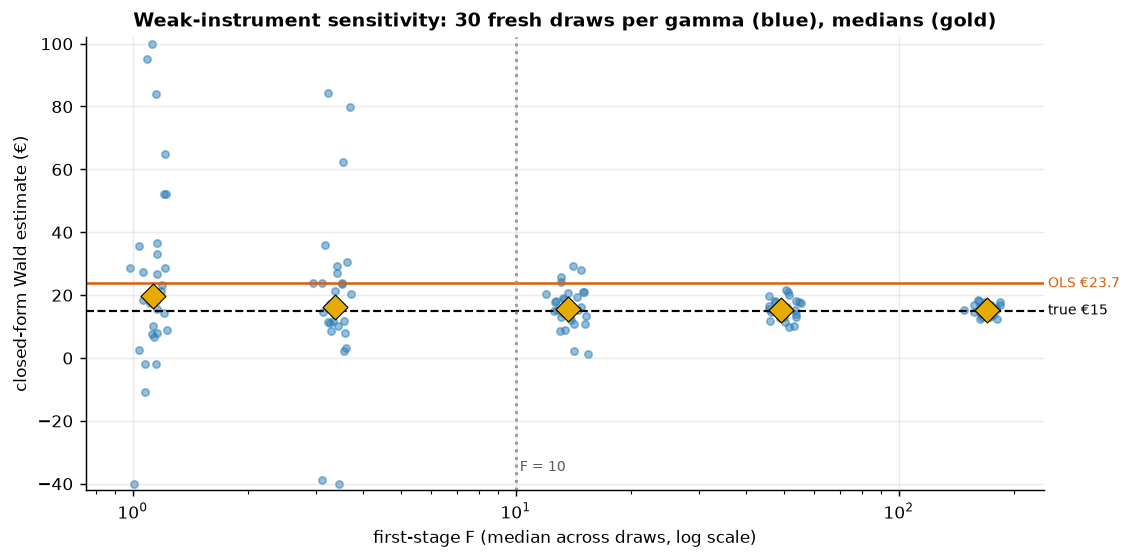

In [9]:
# --- Degrade the instrument on purpose: gamma sweep, closed-form Wald only ---
GAMMAS = [1.1, 0.6, 0.3, 0.15, 0.08]
NSW = 12 if FAST else 30
def _sim_gamma(gamma, n=3000, seed=0):
    # dgp.iv_ad_exposure with the hard-coded 1.1 exposed as a dial (same draw order, same DGM)
    _r = np.random.default_rng(seed)
    _u = _r.normal(0, 1, n); _z = _r.integers(0, 2, n).astype(float)
    _x = (_r.uniform(size=n) < 1.0 / (1.0 + np.exp(-(0.3 + gamma * _z + 0.8 * _u)))).astype(float)
    _y = 50 + TRUE * _x + 12 * _u + _r.normal(0, 6, n)
    return _z, _x, _y
sweep = []
for g in GAMMAS:
    _ws, _Fs = [], []
    for _sd in range(NSW):
        _zg, _xg, _yg = _sim_gamma(g, seed=200 + _sd)
        _Zr = np.column_stack([np.ones(len(_zg)), _zg])
        _red = np.linalg.lstsq(_Zr, _yg, rcond=None)[0][1]
        _fst = np.linalg.lstsq(_Zr, _xg, rcond=None)[0][1]
        _ws.append(_red / _fst); _Fs.append(est.first_stage_F(_zg, _xg))
    sweep.append((g, float(np.median(_Fs)), np.array(_ws)))

fig, ax = plt.subplots(figsize=(8.8, 4.4))
_rj = np.random.default_rng(0)
for g, medF, ws in sweep:
    _xj = medF * np.exp(_rj.normal(0, 0.06, len(ws)))
    ax.scatter(_xj, np.clip(ws, -40, 100), s=16, alpha=0.5, color=plots.BLUE)
    ax.scatter([medF], [np.median(ws)], s=95, marker="D", color=plots.GOLD, zorder=4,
               edgecolor="k", linewidth=0.6)
ax.set_xscale("log"); ax.set_ylim(-42, 102)
ax.axhline(TRUE, color="k", ls="--", lw=1.2); ax.axhline(naive, color=plots.ORANGE, lw=1.4)
ax.axvline(10, color=plots.GREY, ls=":", lw=1.6)
_xmax = ax.get_xlim()[1]
ax.text(_xmax, TRUE, f" true €{TRUE:.0f}", va="center", fontsize=8)
ax.text(_xmax, naive, f" OLS €{naive:.1f}", va="center", fontsize=8, color=plots.ORANGE)
ax.text(10, -36, " F = 10", fontsize=8, color="0.35")
ax.set_xlabel("first-stage F (median across draws, log scale)")
ax.set_ylabel("closed-form Wald estimate (€)")
ax.set_title(f"Weak-instrument sensitivity: {NSW} fresh draws per gamma (blue), medians (gold)")
fig.tight_layout()

for g, medF, ws in sweep:
    _lo, _hi = np.quantile(ws, [0.05, 0.95])
    print(f"  gamma {g:>4}: median F {medF:6.1f}  median Wald €{np.median(ws):5.1f}  "
          f"90% range [{_lo:.1f}, {_hi:.1f}]")
_gw, _medFw, _wsw = sweep[-1]
_lo, _hi = np.quantile(_wsw, [0.05, 0.95])
_n_clip = int(sum(((ws < -40) | (ws > 100)).sum() for _, _, ws in sweep))
_msg = (f"At F ≈ {_medFw:.1f} the 90% range of the IV estimate spans €{_lo:.0f} to €{_hi:.0f} — far wider than\n"
        f"the €{naive - TRUE:.1f} OLS-vs-truth gap it was meant to fix, and the median drifts toward OLS\n"
        f"(€{naive:.1f}): a weak instrument is worse than none — shown, not asserted.")
if _n_clip:
    _msg += f"\n({_n_clip} extreme point(s) clipped to the plot window.)"
print(_msg)

**How to read this.** Each blue column is the *same estimator on the same market* — only the
instrument's strength changes. At the right edge (F in the hundreds, this notebook's regime) the Wald
estimates hug the true €15. Moving left, the spread widens smoothly until, below the dotted F = 10 line,
it explodes: single draws can land below zero or at multiples of the truth, and the gold *median* drifts
up toward the orange OLS line. The mechanism is the 1/F formula read right-to-left — with a
nearly-irrelevant instrument the Wald denominator is sampling noise around zero, so the ratio inherits
OLS's bias *and* enormous variance. That is the precise sense in which **a weak instrument is worse than
none**: OLS is wrong by a known-ish €9 with a tight interval, while a weak IV can be wrong by tens of
euros in either direction *while wearing the costume of a causal estimate*. Lecture takeaway: check F
before believing any IV number, and if F is small, walk away rather than report the ratio.

## 6 · Decide, in euros — and the exclusion-restriction stress test

Budget on the *causal* per-exposure value (IV), not the inflated OLS. But the exclusion restriction is
untestable, so we ask: **what if the encouragement had a small direct effect on sales** (say the lottery
email itself advertises)? We subtract a hypothetical direct effect $\delta$ from the reduced form and
watch the implied causal estimate move — the honest bound on how much a leak would distort the number.


At €10/exposure: causal net €7.7  ·  P(pays) 1.00
  → BUY exposure (to the complier margin)
  P(pays)=1.00 is saturated, not assumed: the whole posterior
  [€14.3, €21.1] sits above €10.
Break-even sweep: exposure clears the 90%-confidence bar up to €15.0/exposure
  (the budget cap); at €17.8 it is a coin flip.
  So the €10 plan has ~€5.0 of headroom per exposure before the call gets tight.
Exclusion stress: the BUY call survives unless the instrument's direct effect
  exceeds δ≈1.4 (out of a €3.5 reduced form) —
  trusting OLS (€24) would overstate the value and overspend.
  (the corrected line is a point-estimate bound — it re-solves the Wald ratio
  at posterior means; carry the IV interval's width alongside it when briefing
  the cap.)


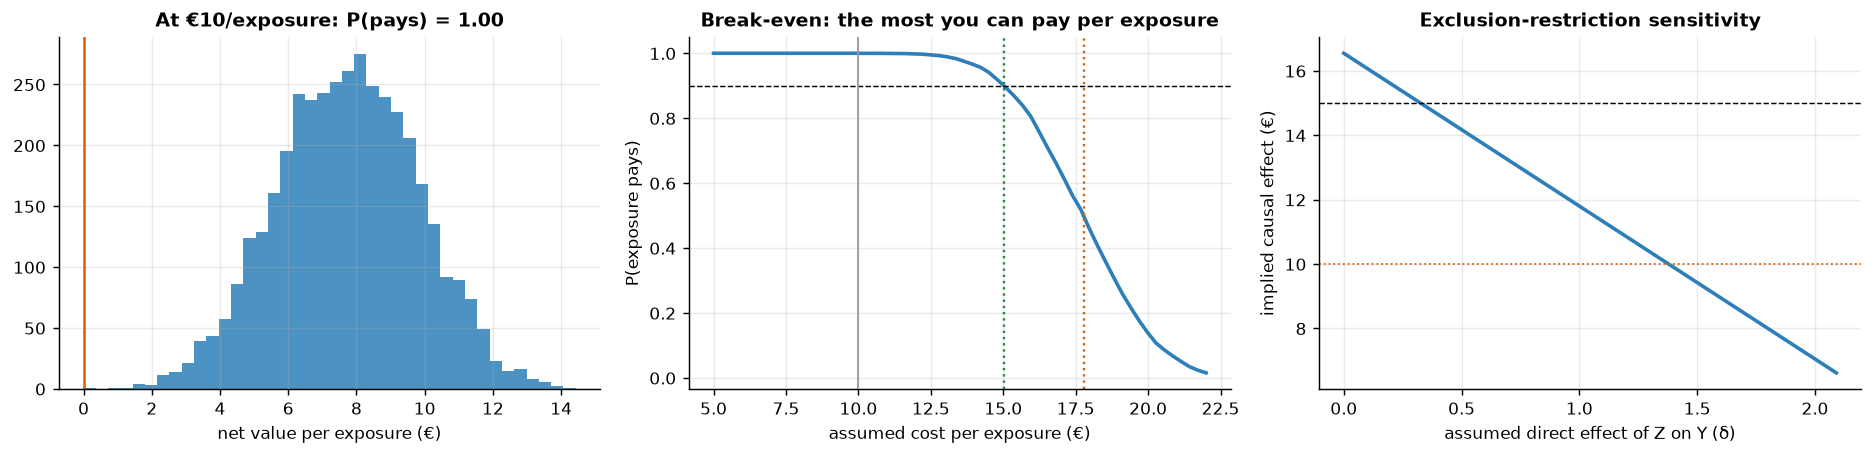

In [10]:
COST = 10.0
net = iv_post - COST; p_worth = (net > 0).mean()
# Break-even cost sweep: the decision rule is BUY when P(effect > c) > 0.9. Sweeping the
# per-exposure cost c turns the single (saturated) P(pays) into a curve and reads off the
# MAX viable cost-per-exposure — the budget cap the opening promised.
costs = np.linspace(5, 22, 60)
p_pays = np.array([(iv_post > c).mean() for c in costs])
c90 = np.quantile(iv_post, 0.10)     # highest cost still clearing P(effect>c) >= 0.90
c50 = np.median(iv_post)             # coin-flip cost (P = 0.50)
# exclusion sensitivity: if Z has a direct effect delta on Y, corrected IV = (reduced - delta)/first
deltas = np.linspace(0, reduced*0.6, 20)
corrected = (reduced - deltas) / first

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].hist(net, bins=40, color=plots.BLUE, alpha=0.85); ax[0].axvline(0, color=plots.ORANGE, lw=1.4)
ax[0].set_xlabel("net value per exposure (€)"); ax[0].set_title(f"At €{COST:.0f}/exposure: P(pays) = {p_worth:.2f}")
ax[1].plot(costs, p_pays, color=plots.BLUE, lw=2)
ax[1].axhline(0.9, color="k", ls="--", lw=0.8); ax[1].axvline(c90, color=plots.GREEN, ls=":", lw=1.3)
ax[1].axvline(c50, color=plots.ORANGE, ls=":", lw=1.3); ax[1].axvline(COST, color=plots.GREY, lw=1)
ax[1].set_xlabel("assumed cost per exposure (€)"); ax[1].set_ylabel("P(exposure pays)")
ax[1].set_title("Break-even: the most you can pay per exposure")
ax[2].plot(deltas, corrected, color=plots.BLUE, lw=2); ax[2].axhline(true_effect, color="k", ls="--", lw=0.8)
ax[2].axhline(COST, color=plots.ORANGE, ls=":", lw=1); ax[2].set_xlabel("assumed direct effect of Z on Y (δ)")
ax[2].set_ylabel("implied causal effect (€)"); ax[2].set_title("Exclusion-restriction sensitivity")
fig.tight_layout()

break_delta = deltas[np.argmax(corrected < COST)] if np.any(corrected < COST) else np.nan
lo, hi = np.quantile(iv_post, 0.05), np.quantile(iv_post, 0.95)
print(f"At €{COST:.0f}/exposure: causal net €{net.mean():.1f}  ·  P(pays) {p_worth:.2f}\n  → "
      + ("BUY exposure (to the complier margin)" if p_worth > 0.9 else "hold"))
print(f"  P(pays)=1.00 is saturated, not assumed: the whole posterior\n"
      f"  [€{lo:.1f}, €{hi:.1f}] sits above €{COST:.0f}.")
print(f"Break-even sweep: exposure clears the 90%-confidence bar up to €{c90:.1f}/exposure\n"
      f"  (the budget cap); at €{c50:.1f} it is a coin flip.\n"
      f"  So the €{COST:.0f} plan has ~€{c90-COST:.1f} of headroom per exposure before the call gets tight.")
print(f"Exclusion stress: the BUY call survives unless the instrument's direct effect\n"
      f"  exceeds δ≈{break_delta:.1f} (out of a €{reduced:.1f} reduced form) —\n"
      f"  trusting OLS (€{naive:.0f}) would overstate the value and overspend.")
print("  (the corrected line is a point-estimate bound — it re-solves the Wald ratio\n"
      "  at posterior means; carry the IV interval's width alongside it when briefing\n"
      "  the cap.)")

**Read-out.** Three numbers make the budget case, one per panel. *Left*: at the current
€10/exposure the **causal** net value is ≈ €8/exposure with the entire posterior above zero — a
saturated BUY, valid for the complier margin the instrument identifies. *Middle*: the sweep turns
the posterior into a procurement cap — the 90%-confidence bar holds up to ≈ **€15/exposure**, the
coin-flip point is ≈ €17.8, so the €10 plan has ~€5 of genuine headroom. *Right*: the stress test
bounds the untestable worry — the BUY survives unless the lottery email itself drives more than
δ ≈ €1.4 of sales directly, which against a €3.5 total reduced form would be a large leak (a plain
encouragement email with no product content makes that implausible; an email that doubles as an ad
does not — design the instrument accordingly). The management contrast to land: budgeting on OLS's
€24 would sanction paying up to €24 for something causally worth ≈ €15 — the €9 gap, times every
exposure bought, is the price of mistaking correlation for incrementality.

### The one-paragraph decision

> **What I'd tell the CMO.** Buy the exposure at the current €10: the causal value per exposure (the IV
> posterior above) sits comfortably clear of cost — P(pays) is saturated — and the break-even sweep caps
> procurement at ≈ €15 per exposure at 90% confidence, coin-flip near €18, so the €10 plan carries
> roughly €5 of headroom. **Scope:** that number is earned on the *complier margin* — the ≈ 21 pp of
> customers the encouragement actually tips into seeing the ad — and says nothing about always-exposed
> loyalists; that is the right scope for this call, because a budget buys *incremental* exposure.
> **Fragility, priced:** the BUY survives a direct-effect leak of the lottery into sales up to
> δ ≈ €1.4 of the €3.5 reduced form (a large leak for a content-free lottery email), and survives the
> small finite-sample bias §5b measured; it would *not* survive a weak instrument — which is why F ≈ 156
> was checked before anything else (§5c shows the crash we avoided). **The mistake we didn't make:**
> budgeting on the naive €23.7 would sanction paying several euros of non-causal value on every
> exposure bought — the cell below prices that error at campaign scale, and the JSON carries every number
> a deck needs.

In [11]:
import json
VOLUME = 1_000_000   # exposures per quarter — a stated planning volume, scale to your buy
overpay = float(naive - iv_post.mean())
lo90, hi90 = float(np.quantile(iv_post, 0.05)), float(np.quantile(iv_post, 0.95))
print(f"Campaign-scale cost of the naive number: an OLS-calibrated cap sanctions\n"
      f"  ≈ €{overpay:.1f} of non-causal value per exposure; at {VOLUME:,} exposures/quarter that\n"
      f"  authorizes ≈ €{overpay * VOLUME / 1e6:.1f}M per quarter for value that does not exist\n"
      f"  (€{(naive - hi90) * VOLUME / 1e6:.1f}M–€{(naive - lo90) * VOLUME / 1e6:.1f}M against the IV 90% interval).")
decision = {
    "true_effect": float(TRUE), "ols": round(float(naive), 2), "wald": round(float(wald), 2),
    "iv_mean": round(float(iv_post.mean()), 2), "iv_ci90": [round(lo90, 2), round(hi90, 2)],
    "first_stage_F": round(float(Fstat), 1), "complier_share_pp": round(float((fs[1] - fs[0]) * 100), 1),
    "rho_mean": (round(float(_rho.mean()), 3) if _rho is not None else None),
    "cost_per_exposure": float(COST), "budget_cap_c90": round(float(c90), 2),
    "coinflip_c50": round(float(c50), 2),
    "exclusion_break_delta": round(float(break_delta), 2),
    "multiseed_bias": round(float(pts.mean() - TRUE), 2), "multiseed_coverage": f"{cov}/{NSEED}",
    "naive_overpay_eur_per_quarter_at_1M": round(float(overpay * VOLUME)),
}
print(json.dumps(decision, indent=2))

Campaign-scale cost of the naive number: an OLS-calibrated cap sanctions
  ≈ €5.9 of non-causal value per exposure; at 1,000,000 exposures/quarter that
  authorizes ≈ €5.9M per quarter for value that does not exist
  (€2.5M–€9.3M against the IV 90% interval).
{
  "true_effect": 15.0,
  "ols": 23.67,
  "wald": 16.55,
  "iv_mean": 17.73,
  "iv_ci90": [
    14.34,
    21.15
  ],
  "first_stage_F": 156.2,
  "complier_share_pp": 21.1,
  "rho_mean": 0.218,
  "cost_per_exposure": 10.0,
  "budget_cap_c90": 15.02,
  "coinflip_c50": 17.77,
  "exclusion_break_delta": 1.43,
  "multiseed_bias": 1.5,
  "multiseed_coverage": "16/20",
  "naive_overpay_eur_per_quarter_at_1M": 5940601
}


## 7 · Caveats

- **LATE, not ATE.** IV speaks only for **compliers** — customers the encouragement moves (the Step-3
  table shows who is silent). Always-exposed loyalists and never-exposed skeptics may respond differently;
  report the scope.
- **Weak instruments are dangerous.** A small first stage (low F) inflates both variance and bias — §5c
  demonstrated the crash: below F ≈ 10 the estimate's spread explodes and its median drifts back toward
  OLS. Check F first (on real data, the Montiel Olea–Pflueger *effective* F), and if it is small, walk
  away rather than report the ratio.
- **Exclusion is untestable.** We formalized it ($Y_i(z,x) = Y_i(x)$), stress-tested it in step 6, and
  priced the leak that would flip the call; defend it on design, not data.
- **Monotonicity (no defiers).** IV's LATE interpretation assumes no one is pushed *away* from exposure by
  encouragement — usually plausible, worth stating (it deleted the defier row in Step 3's derivation).
- **The joint Gaussian is an approximation.** §4b showed the exposure margin failing by construction
  (a 0/1 variable modeled linearly); §5b measured the resulting small bias and mild under-coverage. Read
  the exposure equation's point estimate and $\rho$, never its posterior width.
- **Real data next.** Notebook **11b** replays this playbook on the Criteo uplift dataset — randomized
  assignment as the instrument for actual ad exposure — where F, the complier share, and the budget cap
  must be earned from the data rather than planted in it.